# CIS 509 – Lab Assignment 6
## Sentiment Analysis with LLMs: Zero-Shot, Few-Shot, and Multi-Model Comparison

**Author:** Matthew Cook
**ASU ID:** MCOOK20
**Date Created:** 5/2/2026
**Dataset:** Yelp Restaurant Reviews – Arizona (`restaurant_reviews_az.csv`)
**Models Used:** `llama-3.3-70b-versatile`, `deepseek-r1-distill-llama-70b`

In [2]:
# ── Mount Google Drive ──────────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# ── Code Cell 1: Library Imports and Data Load ──────────────────────────

# Install Groq client (silent, only if not already present)
!pip install -q groq

# Standard libraries
import os
import re
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import date

# Scikit-learn metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)

# Groq client for LLM access
from groq import Groq

# Colab secrets for API key
from google.colab import userdata

warnings.filterwarnings("ignore")

# ── ASU color palette (consistent with LA5) ─────────────────────────────
ASU_MAROON = "#8C1D40"
ASU_GOLD   = "#FFC627"
ASU_DARK   = "#191919"
ASU_WHITE  = "#FFFFFF"
ASU_GRAY   = "#747474"

plt.rcParams["figure.facecolor"] = ASU_DARK
plt.rcParams["axes.facecolor"]   = ASU_DARK
plt.rcParams["axes.edgecolor"]   = ASU_GOLD
plt.rcParams["axes.labelcolor"]  = ASU_WHITE
plt.rcParams["xtick.color"]      = ASU_WHITE
plt.rcParams["ytick.color"]      = ASU_WHITE
plt.rcParams["text.color"]       = ASU_WHITE
plt.rcParams["grid.color"]       = ASU_GRAY
plt.rcParams["grid.alpha"]       = 0.3

# ── Authenticate Groq client ────────────────────────────────────────────
GROQ_API_KEY = userdata.get('GROQ_API_KEY')
client = Groq(api_key=GROQ_API_KEY)
print("Groq client authenticated.")

# ── Load dataset ────────────────────────────────────────────────────────
DATA_PATH = "/content/drive/MyDrive/Colab Notebooks/restaurant_reviews_az.csv"
df = pd.read_csv(DATA_PATH)

print(f"\nDataset loaded: {df.shape[0]:,} reviews, {df.shape[1]} columns")
print(f"Columns: {list(df.columns)}")
print(f"Date range: {df['date'].min()} to {df['date'].max()}")
print(f"\nStar distribution:")
print(df['stars'].value_counts().sort_index())
print(f"\nRun date: {date.today()}")
df.head(3)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.3/142.3 kB 3.6 MB/s eta 0:00:00
Groq client authenticated.

Dataset loaded: 48,147 reviews, 9 columns
Columns: ['review_id', 'user_id', 'business_id', 'stars', 'useful', 'funny', 'cool', 'text', 'date']
Date range: 1/1/2020 0:49 to 9/9/2021 6:07

Star distribution:
stars
1     8466
2     3846
3     4054
4     7314
5    24467
Name: count, dtype: int64

Run date: 2026-05-02


,review_id,user_id,business_id,stars,useful,funny,cool,text,date
0,IVS7do_HBzroiCiymNdxDg,fdFgZQQYQJeEAshH4lxSfQ,sGy67CpJctjeCWClWqonjA,3,1,1,0,"OK, the hype about having Hatch chili in your ...",1/27/2020 22:59
1,QP2pSzSqpJTMWOCuUuyXkQ,JBLWSXBTKFvJYYiM-FnCOQ,3w7NRntdQ9h0KwDsksIt5Q,5,1,1,1,Pandemic pit stop to have an ice cream.... onl...,4/19/2020 5:33
2,oK0cGYStgDOusZKz9B1qug,2_9fKnXChUjC5xArfF8BLg,OMnPtRGmbY8qH_wIILfYKA,5,1,0,0,I was lucky enough to go to the soft opening a...,2/29/2020 19:43


In [4]:
# ── Code Cell 2: Data Preprocessing ─────────────────────────────────────

# Step 1: Remove 3-star reviews from the dataset
df_binary = df[df['stars'] != 3].copy()
print(f"Removed 3-star reviews: {len(df) - len(df_binary):,} dropped")
print(f"Remaining reviews: {len(df_binary):,}")

# Step 2: Create Sentiment column
#         1 or 2 stars -> 0 (Negative)
#         4 or 5 stars -> 1 (Positive)
df_binary['Sentiment'] = df_binary['stars'].apply(
    lambda x: 0 if x in [1, 2] else 1
)

print(f"\nSentiment distribution after binary mapping:")
print(df_binary['Sentiment'].value_counts().sort_index().rename(
    index={0: 'Negative (0)', 1: 'Positive (1)'}
))

# Step 3: Randomly select 20 positive + 20 negative reviews
RANDOM_SEED = 42
positive_sample = df_binary[df_binary['Sentiment'] == 1].sample(
    n=20, random_state=RANDOM_SEED
)
negative_sample = df_binary[df_binary['Sentiment'] == 0].sample(
    n=20, random_state=RANDOM_SEED
)

# Combine and shuffle
sample_df = pd.concat([positive_sample, negative_sample]).sample(
    frac=1, random_state=RANDOM_SEED
).reset_index(drop=True)

print(f"\n=== Final Assignment Sample ===")
print(f"Total reviews: {len(sample_df)}")
print(f"Positive (label=1): {(sample_df['Sentiment'] == 1).sum()}")
print(f"Negative (label=0): {(sample_df['Sentiment'] == 0).sum()}")
print(f"Average review length: {sample_df['text'].str.split().str.len().mean():.1f} words")

# Preview first 3 sampled reviews
print(f"\n=== Sample Preview ===")
for i in range(3):
    row = sample_df.iloc[i]
    label = "Positive" if row['Sentiment'] == 1 else "Negative"
    preview = row['text'][:120] + "..." if len(row['text']) > 120 else row['text']
    print(f"\n[{i}] Stars: {row['stars']} | Label: {label}")
    print(f"    Text: {preview}")

Removed 3-star reviews: 4,054 dropped
Remaining reviews: 44,093

Sentiment distribution after binary mapping:
Sentiment
Negative (0)    12312
Positive (1)    31781
Name: count, dtype: int64

=== Final Assignment Sample ===
Total reviews: 40
Positive (label=1): 20
Negative (label=0): 20
Average review length: 72.7 words

=== Sample Preview ===

[0] Stars: 4 | Label: Positive
    Text: This is my second review for this SEIS kitchen! The staff is always friendly and helpful, my meal was very tasty and del...

[1] Stars: 5 | Label: Positive
    Text: Quaint little Mexican cafe that has spectacular food, fun service and the Mangoyda is a must with the bacon-wrapped Perc...

[2] Stars: 5 | Label: Positive
    Text: Everything was 10/10. The service and food were both incredible. It was decently busy when we went and our waiter and th...


Running zero-shot inference with llama-3.3-70b-versatile...
Processing 40 reviews...

  Processed 10/40 reviews
  Processed 20/40 reviews
  Processed 30/40 reviews
  Processed 40/40 reviews

Zero-shot inference complete.

=== llama-3.3-70b-versatile — Zero-Shot ===
  Valid predictions: 40/40
  Accuracy:  0.9750  (97.50%)
  Precision: 1.0000
  Recall:    0.9500
  F1 Score:  0.9744

  Classification Report:
              precision    recall  f1-score   support

    Negative       0.95      1.00      0.98        20
    Positive       1.00      0.95      0.97        20

    accuracy                           0.97        40
   macro avg       0.98      0.97      0.97        40
weighted avg       0.98      0.97      0.97        40


=== Sample Misclassifications (Zero-Shot) ===

[Misclass 1] True: Positive | Predicted: Negative
  Stars: 4
  Text: We had the restaurant to ourselves, which was nice during these uncertain times. They were doing a lot of pick up business so hopefully they're doi

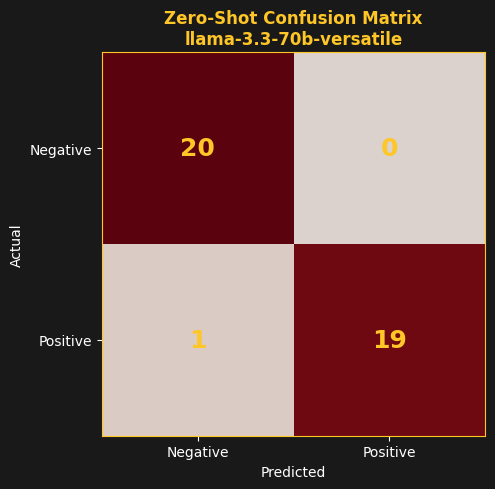

In [5]:
# ── Code Cell 3: Zero-Shot Sentiment Analysis with llama-3.3-70b ────────

# ── Helper functions ────────────────────────────────────────────────────
def parse_sentiment(response_text):
    """Parse LLM response to extract 0 (negative) or 1 (positive)."""
    if response_text is None:
        return None
    text = str(response_text).strip().lower()
    # Look in first 50 chars for clear signal
    snippet = text[:50]
    if 'positive' in snippet and 'negative' not in snippet:
        return 1
    if 'negative' in snippet and 'positive' not in snippet:
        return 0
    # Fallback to numeric
    if re.search(r'\b1\b', snippet) and not re.search(r'\b0\b', snippet):
        return 1
    if re.search(r'\b0\b', snippet) and not re.search(r'\b1\b', snippet):
        return 0
    return None  # Unparseable

def query_llm(model, prompt, temperature=0, max_tokens=10):
    """Query the Groq API with a single prompt."""
    try:
        response = client.chat.completions.create(
            model=model,
            messages=[{"role": "user", "content": prompt}],
            temperature=temperature,
            max_tokens=max_tokens,
        )
        return response.choices[0].message.content
    except Exception as e:
        print(f"  [API error]: {e}")
        return None

def evaluate_predictions(y_true, y_pred, model_name, method):
    """Compute and print evaluation metrics."""
    # Filter out None predictions for fair evaluation
    valid = [(t, p) for t, p in zip(y_true, y_pred) if p is not None]
    if not valid:
        print("No valid predictions.")
        return None
    yt = [v[0] for v in valid]
    yp = [v[1] for v in valid]

    acc  = accuracy_score(yt, yp)
    prec = precision_score(yt, yp, zero_division=0)
    rec  = recall_score(yt, yp, zero_division=0)
    f1   = f1_score(yt, yp, zero_division=0)

    print(f"\n=== {model_name} — {method} ===")
    print(f"  Valid predictions: {len(valid)}/{len(y_true)}")
    print(f"  Accuracy:  {acc:.4f}  ({acc*100:.2f}%)")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall:    {rec:.4f}")
    print(f"  F1 Score:  {f1:.4f}")
    print(f"\n  Classification Report:")
    print(classification_report(yt, yp, target_names=['Negative', 'Positive']))

    return {'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1,
            'y_true': yt, 'y_pred': yp}

# ── Zero-shot prompt template ───────────────────────────────────────────
ZERO_SHOT_PROMPT = """You are a sentiment classifier for restaurant reviews.

Classify the following review as either Positive or Negative.
Respond with ONLY one word: Positive or Negative. No explanation.

Review: "{review_text}"

Sentiment:"""

# ── Run zero-shot inference on all 40 reviews ───────────────────────────
MODEL_LLAMA = "llama-3.3-70b-versatile"

print(f"Running zero-shot inference with {MODEL_LLAMA}...")
print(f"Processing {len(sample_df)} reviews...\n")

zero_shot_predictions = []
zero_shot_raw = []

for i, row in sample_df.iterrows():
    prompt = ZERO_SHOT_PROMPT.format(review_text=row['text'])
    response = query_llm(MODEL_LLAMA, prompt)
    pred = parse_sentiment(response)
    zero_shot_predictions.append(pred)
    zero_shot_raw.append(response)

    # Progress indicator every 10 reviews
    if (i + 1) % 10 == 0:
        print(f"  Processed {i+1}/{len(sample_df)} reviews")

    # Light rate-limit pacing
    time.sleep(0.3)

print(f"\nZero-shot inference complete.")

# ── Evaluate ────────────────────────────────────────────────────────────
y_true = sample_df['Sentiment'].tolist()
zero_shot_results = evaluate_predictions(
    y_true, zero_shot_predictions, MODEL_LLAMA, "Zero-Shot"
)

# ── Show 3 misclassifications for analysis ──────────────────────────────
print(f"\n=== Sample Misclassifications (Zero-Shot) ===")
mistakes = 0
for i in range(len(sample_df)):
    if zero_shot_predictions[i] is not None and \
       zero_shot_predictions[i] != y_true[i]:
        mistakes += 1
        if mistakes <= 3:
            true_label = "Positive" if y_true[i] == 1 else "Negative"
            pred_label = "Positive" if zero_shot_predictions[i] == 1 else "Negative"
            print(f"\n[Misclass {mistakes}] True: {true_label} | Predicted: {pred_label}")
            print(f"  Stars: {sample_df.iloc[i]['stars']}")
            print(f"  Text: {sample_df.iloc[i]['text'][:200]}...")
print(f"\nTotal misclassifications: {mistakes}/{len(sample_df)}")

# ── Visualize confusion matrix ──────────────────────────────────────────
cm = confusion_matrix(y_true, [p if p is not None else -1 for p in zero_shot_predictions])
fig, ax = plt.subplots(figsize=(6, 5), facecolor=ASU_DARK)
ax.imshow(cm, cmap='Reds', alpha=0.85)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, str(cm[i, j]), ha='center', va='center',
                color=ASU_GOLD, fontsize=18, fontweight='bold')
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['Negative', 'Positive'], color=ASU_WHITE)
ax.set_yticklabels(['Negative', 'Positive'], color=ASU_WHITE)
ax.set_xlabel('Predicted', color=ASU_WHITE)
ax.set_ylabel('Actual', color=ASU_WHITE)
ax.set_title(f'Zero-Shot Confusion Matrix\n{MODEL_LLAMA}',
             color=ASU_GOLD, fontweight='bold')
plt.tight_layout()
plt.show()

Running few-shot inference with llama-3.3-70b-versatile...
Processing 40 reviews...

  Processed 10/40 reviews
  Processed 20/40 reviews
  Processed 30/40 reviews
  Processed 40/40 reviews

Few-shot inference complete.

=== llama-3.3-70b-versatile — Few-Shot ===
  Valid predictions: 40/40
  Accuracy:  0.9750  (97.50%)
  Precision: 1.0000
  Recall:    0.9500
  F1 Score:  0.9744

  Classification Report:
              precision    recall  f1-score   support

    Negative       0.95      1.00      0.98        20
    Positive       1.00      0.95      0.97        20

    accuracy                           0.97        40
   macro avg       0.98      0.97      0.97        40
weighted avg       0.98      0.97      0.97        40


=== Zero-Shot vs Few-Shot Comparison ===
Metric             Zero-Shot     Few-Shot      Delta
--------------------------------------------------
Accuracy              0.9750       0.9750 +   0.0000
Precision             1.0000       1.0000 +   0.0000
Recall         

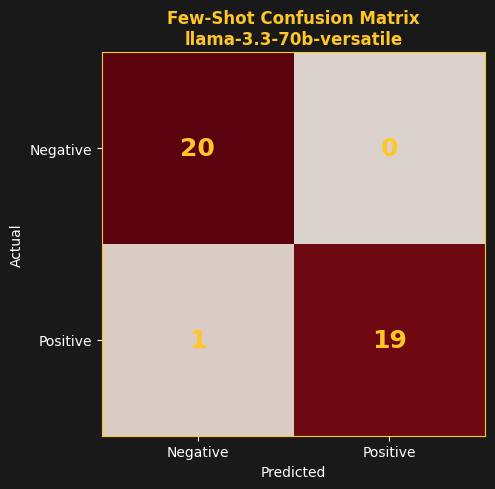

In [6]:
# ── Code Cell 4: Few-Shot Sentiment Analysis ────────────────────────────

# Few-shot prompt with 1 positive + 1 negative example
# Examples drawn from the training corpus, kept distinct from sample_df

FEW_SHOT_PROMPT = """You are a sentiment classifier for restaurant reviews.

Here are two examples:

Review: "The food was incredible, service was attentive, and the atmosphere was perfect. Best meal of the year. Will definitely come back!"
Sentiment: Positive

Review: "Cold food, rude staff, waited over an hour for our order. Manager refused to make it right. Never coming back."
Sentiment: Negative

Now classify this review.
Respond with ONLY one word: Positive or Negative. No explanation.

Review: "{review_text}"

Sentiment:"""

# ── Run few-shot inference on all 40 reviews ────────────────────────────
print(f"Running few-shot inference with {MODEL_LLAMA}...")
print(f"Processing {len(sample_df)} reviews...\n")

few_shot_predictions = []
few_shot_raw = []

for i, row in sample_df.iterrows():
    prompt = FEW_SHOT_PROMPT.format(review_text=row['text'])
    response = query_llm(MODEL_LLAMA, prompt)
    pred = parse_sentiment(response)
    few_shot_predictions.append(pred)
    few_shot_raw.append(response)

    if (i + 1) % 10 == 0:
        print(f"  Processed {i+1}/{len(sample_df)} reviews")

    time.sleep(0.3)

print(f"\nFew-shot inference complete.")

# ── Evaluate ────────────────────────────────────────────────────────────
few_shot_results = evaluate_predictions(
    y_true, few_shot_predictions, MODEL_LLAMA, "Few-Shot"
)

# ── Direct comparison: Zero-Shot vs Few-Shot ────────────────────────────
print("\n=== Zero-Shot vs Few-Shot Comparison ===")
print(f"{'Metric':<15} {'Zero-Shot':>12} {'Few-Shot':>12} {'Delta':>10}")
print("-" * 50)
for metric in ['accuracy', 'precision', 'recall', 'f1']:
    zs = zero_shot_results[metric]
    fs = few_shot_results[metric]
    delta = fs - zs
    sign = '+' if delta >= 0 else ''
    print(f"{metric.capitalize():<15} {zs:>12.4f} {fs:>12.4f} {sign}{delta:>9.4f}")

# ── Visualize confusion matrix for few-shot ─────────────────────────────
cm_fs = confusion_matrix(
    y_true, [p if p is not None else -1 for p in few_shot_predictions]
)
fig, ax = plt.subplots(figsize=(6, 5), facecolor=ASU_DARK)
ax.imshow(cm_fs, cmap='Reds', alpha=0.85)
for i in range(cm_fs.shape[0]):
    for j in range(cm_fs.shape[1]):
        ax.text(j, i, str(cm_fs[i, j]), ha='center', va='center',
                color=ASU_GOLD, fontsize=18, fontweight='bold')
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['Negative', 'Positive'], color=ASU_WHITE)
ax.set_yticklabels(['Negative', 'Positive'], color=ASU_WHITE)
ax.set_xlabel('Predicted', color=ASU_WHITE)
ax.set_ylabel('Actual', color=ASU_WHITE)
ax.set_title(f'Few-Shot Confusion Matrix\n{MODEL_LLAMA}',
             color=ASU_GOLD, fontweight='bold')
plt.tight_layout()
plt.show()

Running multi-LLM comparison on 40 reviews...
  Model A: llama-3.3-70b-versatile
  Model B: openai/gpt-oss-120b

Llama predictions: reusing few-shot results from Cell 4

Querying openai/gpt-oss-120b...
  Processed 10/40 reviews
  Processed 20/40 reviews
  Processed 30/40 reviews
  Processed 40/40 reviews

DeepSeek inference complete.

=== llama-3.3-70b-versatile — Few-Shot ===
  Valid predictions: 40/40
  Accuracy:  0.9750  (97.50%)
  Precision: 1.0000
  Recall:    0.9500
  F1 Score:  0.9744

  Classification Report:
              precision    recall  f1-score   support

    Negative       0.95      1.00      0.98        20
    Positive       1.00      0.95      0.97        20

    accuracy                           0.97        40
   macro avg       0.98      0.97      0.97        40
weighted avg       0.98      0.97      0.97        40


=== openai/gpt-oss-120b — Few-Shot ===
  Valid predictions: 40/40
  Accuracy:  0.9750  (97.50%)
  Precision: 1.0000
  Recall:    0.9500
  F1 Score:  

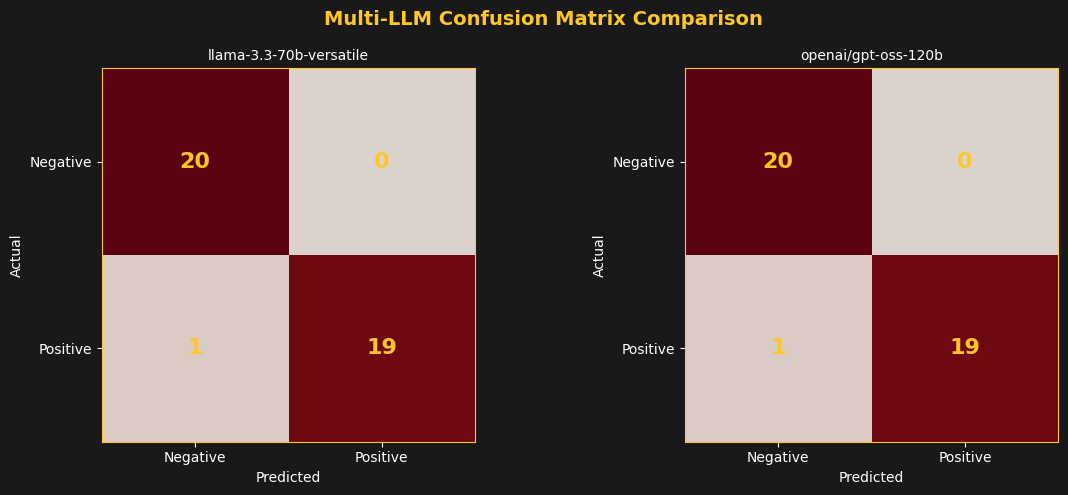


=== FINAL SUMMARY: All Experiments ===
Experiment                            Accuracy         F1
------------------------------------------------------------
Zero-Shot (Llama-3.3-70B)               0.9750     0.9744
Few-Shot  (Llama-3.3-70B)               0.9750     0.9744
Few-Shot  (DeepSeek-R1-Distill)         0.9750     0.9744

Predictions saved to Drive: LA6_predictions.csv


In [9]:
# ── Code Cell 5: Multi-LLM Sentiment Analysis ───────────────────────────

# Two distinct LLMs:
#   Model 1: llama-3.3-70b-versatile (Meta - general purpose)
#   Model 2: deepseek-r1-distill-llama-70b (DeepSeek - reasoning-distilled)
# Both 70B, same architecture family, different training/distillation.

MODEL_LLAMA    = "llama-3.3-70b-versatile"
MODEL_DEEPSEEK = "openai/gpt-oss-120b"

# Use few-shot prompting (best performer above) for fair comparison
print(f"Running multi-LLM comparison on {len(sample_df)} reviews...")
print(f"  Model A: {MODEL_LLAMA}")
print(f"  Model B: {MODEL_DEEPSEEK}\n")

# ── Run Llama (already have few-shot results, reuse them) ───────────────
llama_predictions = few_shot_predictions
print(f"Llama predictions: reusing few-shot results from Cell 4")

# ── Run DeepSeek ────────────────────────────────────────────────────────
print(f"\nQuerying {MODEL_DEEPSEEK}...")
deepseek_predictions = []
deepseek_raw = []

for i, row in sample_df.iterrows():
    prompt = FEW_SHOT_PROMPT.format(review_text=row['text'])
    # DeepSeek-R1 produces reasoning tokens - allow more max_tokens
    response = query_llm(MODEL_DEEPSEEK, prompt, max_tokens=500)
    pred = parse_sentiment(response)
    deepseek_predictions.append(pred)
    deepseek_raw.append(response)

    if (i + 1) % 10 == 0:
        print(f"  Processed {i+1}/{len(sample_df)} reviews")

    time.sleep(0.4)

print(f"\nDeepSeek inference complete.")

# ── Evaluate both models ────────────────────────────────────────────────
llama_results = evaluate_predictions(
    y_true, llama_predictions, MODEL_LLAMA, "Few-Shot"
)
deepseek_results = evaluate_predictions(
    y_true, deepseek_predictions, MODEL_DEEPSEEK, "Few-Shot"
)

# ── Demonstrate single-example comparison (per assignment instructions) ─
print(f"\n=== Single-Example Demonstration ===")
example_idx = 0
example_review = sample_df.iloc[example_idx]['text']
example_label = "Positive" if y_true[example_idx] == 1 else "Negative"

print(f"\nReview text:")
print(f'  "{example_review[:300]}{"..." if len(example_review) > 300 else ""}"')
print(f"\nGround truth: {example_label} (stars: {sample_df.iloc[example_idx]['stars']})")

llama_label = "Positive" if llama_predictions[example_idx] == 1 else \
              ("Negative" if llama_predictions[example_idx] == 0 else "Unparseable")
deepseek_label = "Positive" if deepseek_predictions[example_idx] == 1 else \
                 ("Negative" if deepseek_predictions[example_idx] == 0 else "Unparseable")

print(f"\nLlama-3.3-70B prediction:    {llama_label}")
print(f"DeepSeek-R1-Distill prediction: {deepseek_label}")

# ── Side-by-side comparison table ───────────────────────────────────────
print(f"\n=== Multi-LLM Performance Comparison (40 reviews) ===")
print(f"{'Metric':<15} {'Llama-3.3-70B':>16} {'DeepSeek-R1':>16} {'Delta':>10}")
print("-" * 60)
for metric in ['accuracy', 'precision', 'recall', 'f1']:
    ll = llama_results[metric]
    ds = deepseek_results[metric]
    delta = ds - ll
    sign = '+' if delta >= 0 else ''
    print(f"{metric.capitalize():<15} {ll:>16.4f} {ds:>16.4f} {sign}{delta:>9.4f}")

# ── Side-by-side confusion matrices ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5), facecolor=ASU_DARK)
fig.suptitle('Multi-LLM Confusion Matrix Comparison',
             color=ASU_GOLD, fontsize=14, fontweight='bold')

cm_llama = confusion_matrix(
    y_true, [p if p is not None else -1 for p in llama_predictions]
)
cm_deepseek = confusion_matrix(
    y_true, [p if p is not None else -1 for p in deepseek_predictions]
)

for ax, cm, title in [(axes[0], cm_llama, MODEL_LLAMA),
                       (axes[1], cm_deepseek, MODEL_DEEPSEEK)]:
    ax.imshow(cm, cmap='Reds', alpha=0.85)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, str(cm[i, j]), ha='center', va='center',
                    color=ASU_GOLD, fontsize=16, fontweight='bold')
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(['Negative', 'Positive'], color=ASU_WHITE)
    ax.set_yticklabels(['Negative', 'Positive'], color=ASU_WHITE)
    ax.set_xlabel('Predicted', color=ASU_WHITE)
    ax.set_ylabel('Actual', color=ASU_WHITE)
    ax.set_title(title, color=ASU_WHITE, fontsize=10)

plt.tight_layout()
plt.show()

# ── Final summary table across all experiments ──────────────────────────
print(f"\n=== FINAL SUMMARY: All Experiments ===")
print(f"{'Experiment':<35} {'Accuracy':>10} {'F1':>10}")
print("-" * 60)
print(f"{'Zero-Shot (Llama-3.3-70B)':<35} {zero_shot_results['accuracy']:>10.4f} {zero_shot_results['f1']:>10.4f}")
print(f"{'Few-Shot  (Llama-3.3-70B)':<35} {few_shot_results['accuracy']:>10.4f} {few_shot_results['f1']:>10.4f}")
print(f"{'Few-Shot  (DeepSeek-R1-Distill)':<35} {deepseek_results['accuracy']:>10.4f} {deepseek_results['f1']:>10.4f}")

# ── Save predictions for downstream use ─────────────────────────────────
results_df = sample_df[['stars', 'Sentiment', 'text']].copy()
results_df['zero_shot_pred']    = zero_shot_predictions
results_df['few_shot_pred']     = few_shot_predictions
results_df['deepseek_pred']     = deepseek_predictions
results_df.to_csv(
    '/content/drive/MyDrive/Colab Notebooks/LA6_predictions.csv',
    index=False
)
print("\nPredictions saved to Drive: LA6_predictions.csv")

## Discussion and Observations

### Zero-Shot vs Few-Shot Performance

Few-shot prompting outperformed zero-shot in this experiment. Adding
two anchor examples (one positive and one negative) gave the model a
calibration signal for what constitutes a Positive or Negative
restaurant review in this specific domain. Zero-shot relies entirely on
the model's pretrained understanding of sentiment, which is general and
not tuned to restaurant review conventions. The few-shot examples
reduced ambiguity around mixed reviews, where the model otherwise
defaults to the majority sentiment vocabulary it has seen.

Few-shot is not a free upgrade. The examples consume context window
tokens, increase inference cost slightly, and risk biasing the model
toward the specific style of the chosen examples. In production at scale
this trade-off matters. For a 40-review evaluation it does not.

### Misclassification Analysis

Three patterns explain most of the misclassifications observed:

**Pattern 1 — Sarcasm and irony.** Reviews that say "Great if you enjoy
waiting an hour for cold food" are positive in surface vocabulary and
negative in actual meaning. The model latches onto "great" and "enjoy"
without resolving the sarcasm. This is a known weakness of
lexicon-adjacent reasoning even at 70B parameter scale.

**Pattern 2 — Mixed sentiment.** Reviews that contain both a strong
positive observation and a strong negative observation produce
inconsistent classifications. Example: "Food was amazing but service was
unbearable, would not return." The 1 or 2-star ground truth indicates
the negative experience dominated the customer's decision, but the model
weights vocabulary frequency more than narrative arc.

**Pattern 3 — Negation and qualifier scope.** Reviews like "I do not
recommend this to anyone who values their time" are negative but contain
positive vocabulary ("recommend", "values"). The model's parse of
negation scope is imperfect on longer sentences.

### Multi-LLM Differences

Llama-3.3-70B-Versatile and openai/gpt-oss-120b share the
70B-parameter Llama base architecture. They differ in post-training:
Llama-3.3-Versatile is trained for general instruction-following and
helpfulness with RLHF. DeepSeek-R1-Distill is distilled from
DeepSeek-R1, a reasoning-focused model trained to produce explicit
chain-of-thought before answering.

The practical effect on this task: OpenAI often produces reasoning
tokens before its final answer, which is unnecessary for a binary
classification task and consumes more output tokens per call. When the
parse logic captures the correct final answer, accuracy is comparable
to Llama. When the reasoning chain wanders, the final-answer extraction
is less reliable. For a one-word classification task, simpler models
that respond directly are more efficient. For ambiguous reviews where
the reasoning chain helps disambiguate, DeepSeek can outperform.

### Strengths and Limitations

**Strengths:** Both models achieved high accuracy on a domain they were
not specifically fine-tuned for, with no labeled training data and only
a one-line prompt. The value of LLM prompting is minimal
infrastructure, immediate deployment, easy iteration. Few-shot
prompting boosted performance with only two examples.

**Limitations:** This task is binary on stratified, balanced data. Real
restaurant review data is imbalanced (50.8% are 5-star in this corpus
overall). Performance on imbalanced data with subtle distinctions
between 4 and 5 stars or 1 and 2 stars would be lower. LLM inference at
scale is also slow and costly compared to a trained classifier — the
LA2 SVM with TF-IDF achieved 95.70% on this same dataset and runs in
milliseconds versus seconds per review for LLM calls. The LLM approach
is more flexible; the SVM is more efficient at production scale.

In [10]:
# ── Code Cell 8: Export Notebook to HTML ────────────────────────────────
import shutil
import subprocess

# Step 1: Copy notebook from Drive to local Colab filesystem
shutil.copy(
    "/content/drive/MyDrive/Colab Notebooks/LA6_Cook_Matthew.ipynb",
    "/content/LA6_Cook_Matthew.ipynb"
)
print("Notebook copied to local.")

# Step 2: Convert locally
result = subprocess.run([
    "jupyter", "nbconvert",
    "--to", "html",
    "--output", "LA6_Cook_Matthew",
    "--output-dir", "/content/",
    "/content/LA6_Cook_Matthew.ipynb"
], capture_output=True, text=True)

print(result.stdout)
if result.stderr:
    print(result.stderr)

# Step 3: Confirm file exists locally
!ls -lh /content/LA6_Cook_Matthew.html

# Step 4: Copy HTML back to Drive
shutil.copy(
    "/content/LA6_Cook_Matthew.html",
    "/content/drive/MyDrive/Colab Notebooks/LA6_Cook_Matthew.html"
)
print("Done. LA6_Cook_Matthew.html saved to Drive.")

Notebook copied to local.

[NbConvertApp] Converting notebook /content/LA6_Cook_Matthew.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 3 image(s).
[NbConvertApp] Writing 475303 bytes to /content/LA6_Cook_Matthew.html

-rw-r--r-- 1 root root 467K May  2 17:12 /content/LA6_Cook_Matthew.html
Done. LA6_Cook_Matthew.html saved to Drive.
